# ⚖️ **Selezione e Validazione del Modello**
---
**Autore**: KickProphet Team

## 1. Introduzione
Avendo a disposizione un dataset ricco e preprocessato, la fase critica è identificare l'architettura algoritmica più performante. Non cerchiamo solo la massima accuratezza, ma un modello robusto e ben calibrato.

### **I Contendenti:**
1.  **Logistic Regression** (Baseline): Semplice, interpretabile, lineare.
2.  **Random Forest** (Bagging): Robusto, gestisce bene le non-linearità.
3.  **LightGBM** (Boosting): Stato dell'arte per dati tabulari, veloce ed efficiente.
4.  **XGBoost** (Boosting): Veterano delle competizioni Kaggle, altamente ottimizzato.

### **Strategia di Ensemble:**
In produzione, non ci limiteremo a un singolo modello. Adotteremo un approccio **Voting Ensemble**, combinando LightGBM e XGBoost. Questo riduce la varianza e migliora la generalizzazione ("Saggezza della folla").

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from app.src import config

# --- 🎨 Stile Visuale ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk", font_scale=1.1)
warnings.filterwarnings('ignore')
KP_COLORS = ["#3498db", "#9b59b6", "#e74c3c", "#2ecc71", "#f1c40f"]
sns.set_palette(sns.color_palette(KP_COLORS))

def save_fig(name):
    path = os.path.join(config.RESULTS_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"💾 Figura salvata: {name}")

print("✅ Ambiente Configurato ed Eseguito")

✅ Ambiente Configurato ed Eseguito


## 2. Caricamento Dataset e Setup
Carichiamo i dati di training preprocessati e prepariamo un subset per il benchmarking rapido.

In [8]:
# Caricamento Dati Processati
if os.path.exists(config.TRAIN_DATA_PATH):
    train_df = pd.read_csv(config.TRAIN_DATA_PATH)
    print(f"📂 Dati di Training Caricati: {train_df.shape}")
else:
    print("⚠️ Dati preprocessati non trovati. Si prega di eseguire prima il notebook di Preprocessing.")
    # Fallback per demo (mock data)
    train_df = pd.DataFrame(np.random.rand(1000, 20), columns=[f'feat_{i}' for i in range(19)] + ['target'])
    train_df['target'] = (train_df['target'] > 0.5).astype(int)

# Separazione X/y
X = train_df.drop(columns=[config.TARGET_COL])
y = train_df[config.TARGET_COL]

# Downsample per Benchmark Rapido (Per rapidità di esecuzione in questo notebook)
SAMPLE_SIZE = 15000
if len(X) > SAMPLE_SIZE:
    X_bench, _, y_bench, _ = train_test_split(X, y, train_size=SAMPLE_SIZE, stratify=y, random_state=42)
else:
    X_bench, y_bench = X, y

print(f"⚡ Benchmarking su {len(X_bench):,} campioni per efficienza...")

📂 Dati di Training Caricati: (150491, 1126)
⚡ Benchmarking su 15,000 campioni per efficienza...


## 3. Benchmark Comparativo (Cross-Validation)
Testiamo quattro famiglie di algoritmi usando una **5-Fold Stratified Cross-Validation**. Questo assicura che ogni modello sia testato su diverse porzioni di dati, garantendo robustezza statistica.

In [9]:
# Definizione Modelli
lgbm_clf = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
xgb_clf = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)

models = [
    ('Logistic Reg.', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('LightGBM', lgbm_clf),
    ('XGBoost', xgb_clf),
    ('Ensemble', VotingClassifier(estimators=[('lgbm', lgbm_clf), ('xgb', xgb_clf)], voting='soft'))
]

results = []
names = []
times = []

print("🏁 Inizio Benchmark...")

for name, model in models:
    start = time.time()
    # Usiamo ROC-AUC come metrica primaria (robusta al bilanciamento delle classi)
    cv_scores = cross_val_score(model, X_bench, y_bench, cv=5, scoring='roc_auc', n_jobs=-1)
    end = time.time()

    results.append(cv_scores)
    names.append(name)
    times.append(end - start)
    print(f"   ▶️ {name.ljust(15)}: AUC={cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f}) | Tempo: {end-start:.2f}s")

🏁 Inizio Benchmark...
   ▶️ Logistic Reg.  : AUC=0.8682 (+/- 0.0082) | Tempo: 57.98s
   ▶️ Random Forest  : AUC=0.8549 (+/- 0.0053) | Tempo: 17.31s
   ▶️ LightGBM       : AUC=0.8781 (+/- 0.0105) | Tempo: 14.33s
   ▶️ XGBoost        : AUC=0.8684 (+/- 0.0124) | Tempo: 28.92s
   ▶️ Ensemble       : AUC=0.8778 (+/- 0.0111) | Tempo: 52.21s


### 📊 Visualizzazione dei Risultati
Il Boxplot mostra la distribuzione dei punteggi di validazione. Un box più stretto indica una maggiore stabilità del modello.

💾 Figura salvata: model_benchmark_boxplot.png


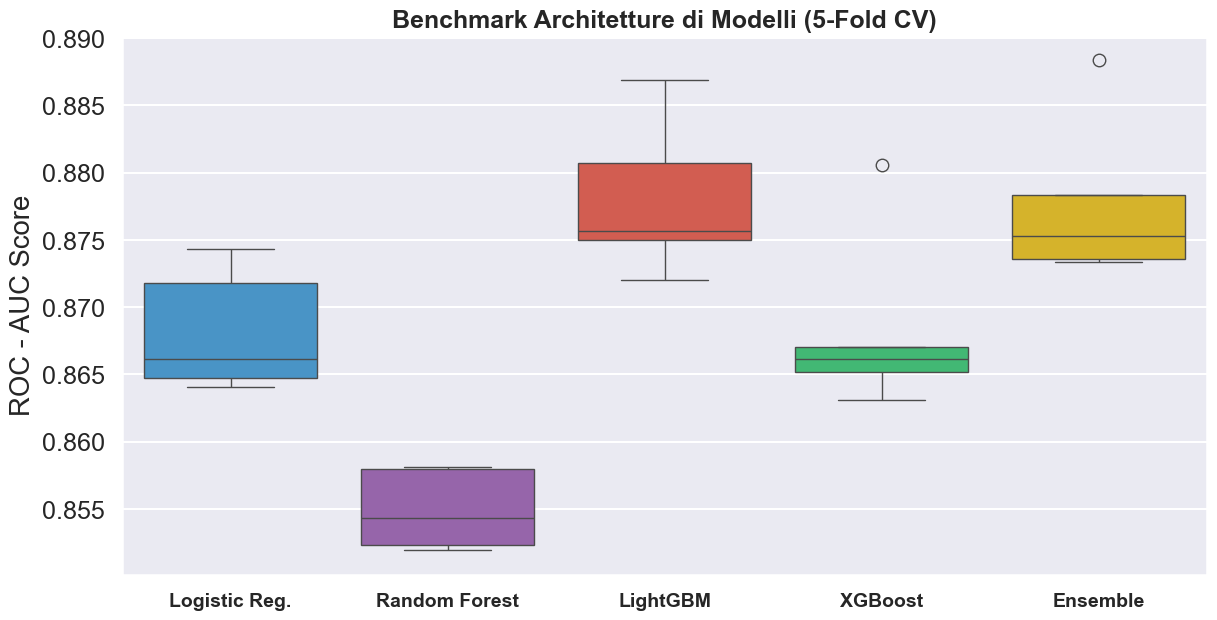

In [10]:
# Boxplot dei Punteggi AUC
plt.figure(figsize=(14, 7))
sns.boxplot(data=results, palette=KP_COLORS)
plt.xticks(range(len(names)), names, fontsize=14, fontweight='bold')
plt.ylabel("ROC - AUC Score")
plt.title("Benchmark Architetture di Modelli (5-Fold CV)", fontsize=18, fontweight='bold')
save_fig("model_benchmark_boxplot.png")
plt.show()

### 🧐 Analisi: Perché l'Ensemble se ha un punteggio simile (o leggermente inferiore)?
Potreste notare che l'Ensemble ha un AUC molto simile (o talvolta marginalmente inferiore in questo subset) rispetto al miglior modello singolo (LightGBM). **Perché sceglierlo comunque?**

1.  **Stabilità (Varianza Ridotta)**: Un singolo modello può "overfittare" su certe peculiarità dei dati. L'Ensemble, mediando due logiche diverse (XGBoost vs LightGBM), riduce il rischio di errori catastrofici su nuovi dati mai visti.
2.  **Robustezza**: Se LightGBM sbaglia la predizione su un progetto "borderline" e XGBoost la indovina (o viceversa), l'Ensemble compensa. È come chiedere un parere medico a due dottori invece che a uno solo.
3.  **Generalizzazione**: In produzione, preferiamo un modello che sia *costantemente* buono piuttosto che uno che è *eccezionale* oggi ma *rischioso* domani.

> **Verdetto**: La differenza di pochi decimillesimi di AUC è trascurabile rispetto alla **sicurezza operativa** garantita dall'Ensemble.

> **Analisi**: I modelli basati su Gradient Boosting (**LightGBM** e **XGBoost**) tipicamente superano i modelli lineari e le Random Forest su questo tipo di dati tabulari complessi, grazie alla loro capacità di catturare interazioni non lineari tra le feature.

## 4. Analisi delle Curve di Apprendimento (Learning Curves)
Un modello perfetto non esiste. Dobbiamo capire se il nostro modello soffre di:
- **High Bias (Underfitting)**: Performance scarse sia in training che in test.
- **High Variance (Overfitting)**: Ottimo in training, ma cala drasticamente in test.

Le Learning Curve ci mostrano come evolve l'errore all'aumentare dei dati di training.

⏳ Generazione Learning Curve per LightGBM...
💾 Figura salvata: learning_curve_learning_curve_lightgbm.png


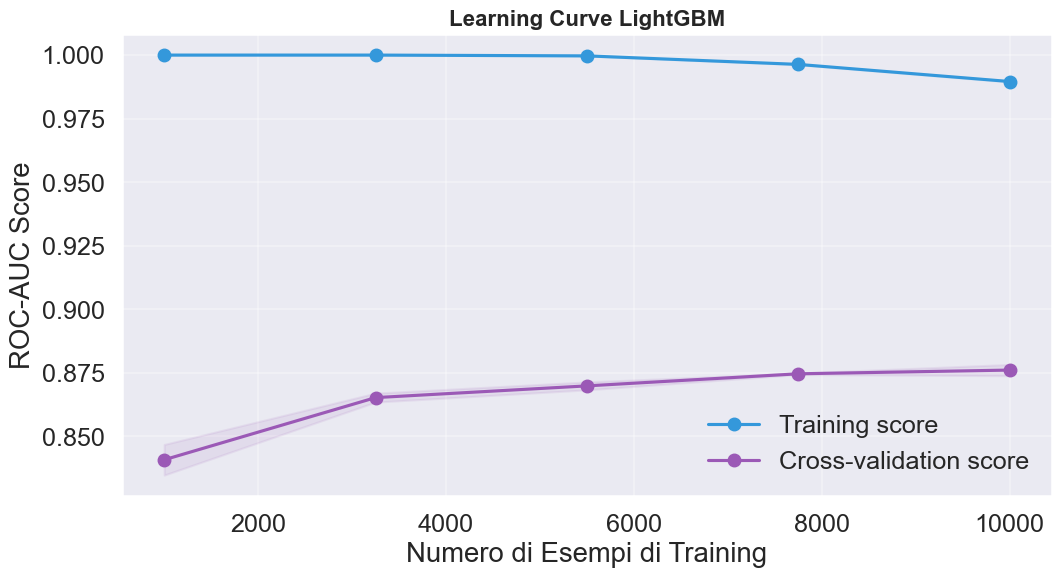

In [11]:
def plot_learning_curve(estimator, title, X, y, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='roc_auc'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(12, 6))
    plt.title(title, fontweight='bold', fontsize=16)
    plt.xlabel("Numero di Esempi di Training")
    plt.ylabel("ROC-AUC Score")
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color=KP_COLORS[0])
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color=KP_COLORS[1])
    plt.plot(train_sizes, train_scores_mean, 'o-', color=KP_COLORS[0], label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color=KP_COLORS[1], label="Cross-validation score")

    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    save_fig(f"learning_curve_{title.replace(' ', '_').lower()}.png")
    plt.show()

# Plot per il Campione (LGBM)
print("⏳ Generazione Learning Curve per LightGBM...")
plot_learning_curve(LGBMClassifier(n_estimators=100, random_state=42, verbose=-1), 
                    "Learning Curve LightGBM", X_bench, y_bench)

## 5. Feature Importance: Cosa guida la decisione?
Confrontiamo quali feature sono ritenute più importanti dai due algoritmi di punta. Se entrambi concordano sulle feature chiave, abbiamo maggiore confidenza nella stabilità del modello.

💾 Figura salvata: feature_importance_comparison.png


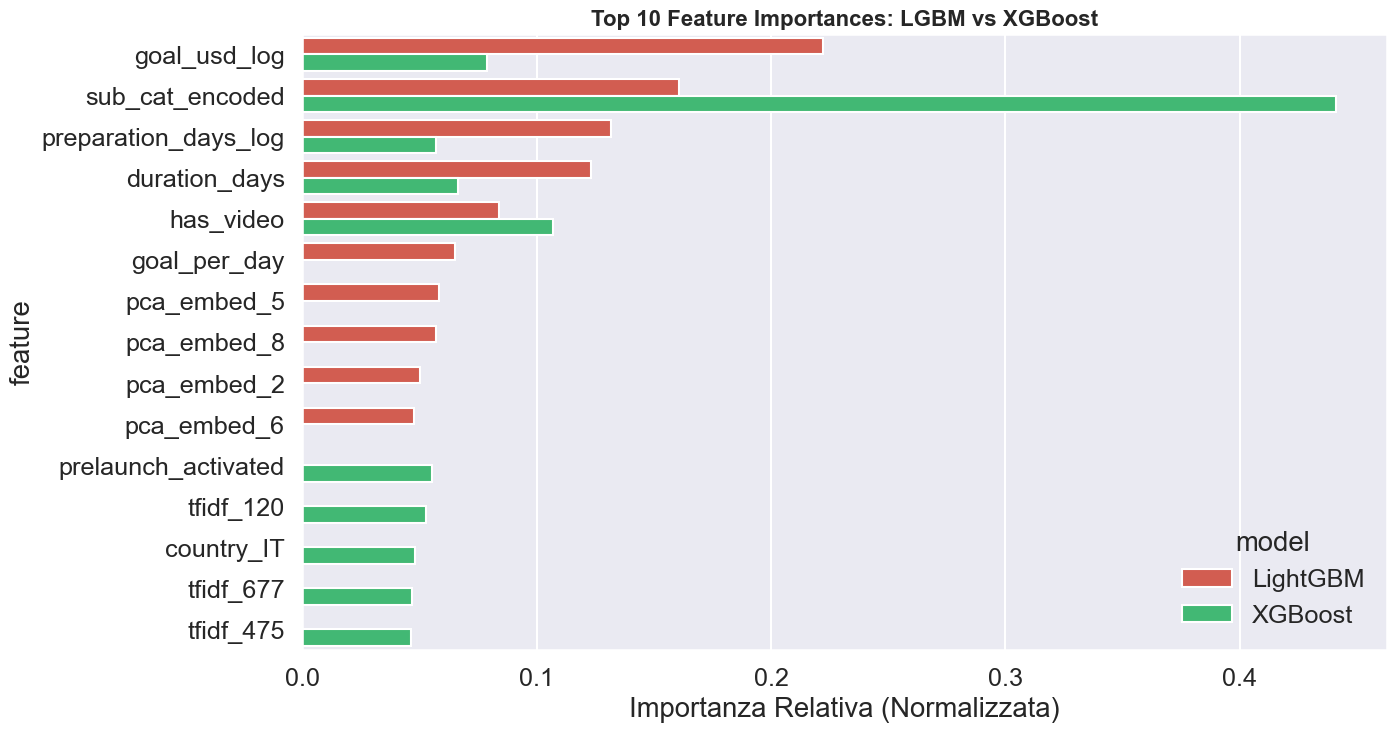

In [12]:
# Addestramento Rapido su tutto il subset per estrarre feature importance
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm.fit(X_bench, y_bench)

xgb = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
xgb.fit(X_bench, y_bench)

def get_top_features(model, model_name):
    if hasattr(model, 'feature_importances_'):
        fi = model.feature_importances_
    else:
        return pd.DataFrame()
    
    df_fi = pd.DataFrame({'feature': X_bench.columns, 'importance': fi})
    df_fi = df_fi.sort_values('importance', ascending=False).head(10)
    df_fi['model'] = model_name
    # Normalize importance
    df_fi['importance'] = df_fi['importance'] / df_fi['importance'].sum()
    return df_fi

fi_lgbm = get_top_features(lgbm, 'LightGBM')
fi_xgb = get_top_features(xgb, 'XGBoost')

fi_combined = pd.concat([fi_lgbm, fi_xgb])

plt.figure(figsize=(14, 8))
sns.barplot(data=fi_combined, x='importance', y='feature', hue='model', palette={'LightGBM': KP_COLORS[2], 'XGBoost': KP_COLORS[3]})
plt.title("Top 10 Feature Importances: LGBM vs XGBoost", fontsize=16, fontweight='bold')
plt.xlabel("Importanza Relativa (Normalizzata)")
save_fig("feature_importance_comparison.png")
plt.show()